# 📊 Workshop Data Science: Mengolah Data Menjadi Cerita Bisnis

**Studi Kasus: Koperasi Susu Boyolali**

---

Diselenggarakan oleh: **Balik Kampoeng**  
Untuk: **SMAN 1 Boyolali**  
Tanggal: **29 Mei 2026**

---

### Misi Hari Ini 🎯

Kalian adalah **analis data muda** yang baru saja direkrut oleh Koperasi Susu Boyolali. Manajer koperasi memberikan kalian data penjualan 3 tahun terakhir dan bertanya:

1. **Bagaimana tren penjualan kami selama 3 tahun terakhir?**
2. **Apakah cuaca/suhu mempengaruhi penjualan produk kami?**
3. **Produk mana yang penjualannya paling stabil, dan mana yang paling fluktuatif?**

Dalam 2,5 jam ke depan, kalian akan **mengubah data mentah ini menjadi insight bisnis** yang bisa dipakai koperasi untuk mengambil keputusan.

Yuk mulai! 🚀


## 1️⃣ Persiapan: Membuka Toolbox Data Science

Sebelum memulai analisis, kita perlu **import library** — semacam 'toolbox' berisi alat-alat yang akan kita pakai.

- `pandas` → untuk mengolah tabel data (seperti Excel, tapi jauh lebih powerful)
- `matplotlib` & `seaborn` → untuk membuat grafik statis
- `plotly` → untuk membuat grafik interaktif (bisa di-zoom, hover, dll)
- `sklearn` → untuk machine learning (regresi linier)


In [3]:
# Import library yang akan kita pakai sepanjang workshop
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression

# Set style supaya grafik kita lebih enak dilihat
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


### 📥 Memuat Dataset

Dataset kita di-host di GitHub. `pd.read_csv()` bisa langsung membaca file CSV dari URL — kita tidak perlu download manual.


In [4]:
# URL dataset di GitHub (raw link)
URL_DATASET = 'https://raw.githubusercontent.com/leonrichandra/bk-datsci/refs/heads/main/dataset_susu_boyolali.csv'

# Muat dataset ke dalam DataFrame (anggap DataFrame seperti tabel Excel)
df = pd.read_csv(URL_DATASET)

print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')


Dataset berhasil dimuat: 5335 baris, 12 kolom


### 🔍 Mengenal Data

Sebelum analisis, kita **wajib** kenalan dulu dengan datanya. Ada 4 fungsi yang selalu dipakai analis data:

| Fungsi | Kegunaan |
|---|---|
| `df.head()` | Lihat 5 baris pertama |
| `df.shape` | Berapa baris × kolom |
| `df.info()` | Tipe data tiap kolom + missing values |
| `df.describe()` | Statistik (rata-rata, min, max, dsb) untuk kolom angka |


In [5]:
# Lihat 5 baris pertama untuk mendapat gambaran data
df.head()


,tanggal,kode_transaksi,jenis_produk,unit_terjual,unit_cost,unit_price,suhu_harian,kelembaban,cuaca,hari,promo_aktif,nama_sales
0,2025-08-23,TRX-20250823-04074,es_krim,86.0,7000,11000,31.4,71.1,berawan,Sabtu,0,Eko Saputra
1,2023-07-19,TRX-20230719-00245,mentega,21.0,25000,40000,29.4,61.8,cerah,Rabu,0,Wati Susilo
2,2024-11-24,TRX-20241124-02712,keju,93.0,35000,47000,29.5,60.3,cerah,Minggu,1,Andi Setiawan
3,2025-01-17,TRX-20250117-02982,keju,24.0,35000,55000,24.0,92.6,hujan,Jumat,0,Joko Pratama
4,2024-02-07,TRX-20240207-01257,keju,21.0,35000,55000,23.8,78.1,berawan,Rabu,0,Siti Aminah


In [6]:
# Ukuran dataset: (jumlah baris, jumlah kolom)
df.shape


(5335, 12)

In [7]:
# Info lengkap: tipe data tiap kolom + jumlah non-null
# Perhatikan: ada kolom yang punya missing values (Non-Null Count < total rows)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5335 entries, 0 to 5334
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tanggal         5335 non-null   object 
 1   kode_transaksi  5335 non-null   object 
 2   jenis_produk    5335 non-null   object 
 3   unit_terjual    5305 non-null   float64
 4   unit_cost       5335 non-null   int64  
 5   unit_price      5335 non-null   int64  
 6   suhu_harian     5310 non-null   float64
 7   kelembaban      5335 non-null   float64
 8   cuaca           5335 non-null   object 
 9   hari            5335 non-null   object 
 10  promo_aktif     5335 non-null   int64  
 11  nama_sales      5335 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 500.3+ KB


In [8]:
# Statistik ringkas untuk kolom numerik
df.describe()


,unit_terjual,unit_cost,unit_price,suhu_harian,kelembaban,promo_aktif
count,5305.000000,5335.000000,5335.000000,5310.000000,5335.000000,5335.000000
mean,53.754006,17001.499531,26405.248360,27.094181,72.759438,0.099344
std,44.833658,11116.099891,17417.077377,2.913692,12.095550,0.299151
min,3.000000,7000.000000,9500.000000,22.000000,50.000000,0.000000
25%,22.000000,8000.000000,12500.000000,24.700000,64.300000,0.000000
50%,37.000000,10000.000000,15500.000000,27.100000,71.600000,0.000000
75%,66.000000,25000.000000,40000.000000,29.500000,82.900000,0.000000
max,262.000000,35000.000000,55000.000000,33.000000,94.900000,1.000000


**Diskusi singkat:** Apa yang kalian perhatikan dari data ini? Ada kolom mana saja? Kira-kira data ini cerita tentang apa?


## 2️⃣ Pembersihan Data (Data Cleaning) 🧹

**Aturan emas data science: Data di dunia nyata SELALU kotor.**

Sebelum bisa dianalisis, data harus dibersihkan dulu. Kalau tidak, hasil analisis kita salah. Ada 3 masalah umum yang akan kita perbaiki hari ini:

1. **Missing values** — ada sel yang kosong
2. **Duplikat** — ada baris yang sama persis muncul berkali-kali
3. **Inkonsistensi penulisan** — misalnya 'susu' vs 'Susu' vs 'SUSU' — komputer menganggap mereka 3 hal berbeda!


### 2.1 Mendeteksi & Mengisi Missing Values

`.isnull().sum()` menghitung berapa banyak nilai kosong (NaN) di setiap kolom.


In [7]:
# Hitung missing values per kolom
df.isnull().sum()


tanggal            0
kode_transaksi     0
jenis_produk       0
unit_terjual      30
unit_cost          0
unit_price         0
suhu_harian       25
kelembaban         0
cuaca              0
hari               0
promo_aktif        0
nama_sales         0
dtype: int64

Terlihat ada missing values di `unit_terjual` dan `suhu_harian`. Bagaimana cara menanganinya?

**Strategi yang kita pakai:**
- `unit_terjual`: isi dengan **median per produk** (karena tiap produk punya range penjualan berbeda)
- `suhu_harian`: isi dengan **mean** (suhu relatif stabil)

Kenapa median untuk `unit_terjual`? Karena median tidak terpengaruh outlier (misalnya hari promo dengan penjualan ekstrim).


In [8]:
# Isi missing unit_terjual dengan median per jenis_produk
# groupby + transform('median') = hitung median tiap grup, lalu kembalikan ke setiap baris
df['unit_terjual'] = df['unit_terjual'].fillna(
    df.groupby('jenis_produk')['unit_terjual'].transform('median')
)

# Isi missing suhu_harian dengan rata-rata seluruh data
df['suhu_harian'] = df['suhu_harian'].fillna(df['suhu_harian'].mean())

# Cek lagi - sekarang harus 0 semua
df.isnull().sum()


tanggal           0
kode_transaksi    0
jenis_produk      0
unit_terjual      0
unit_cost         0
unit_price        0
suhu_harian       0
kelembaban        0
cuaca             0
hari              0
promo_aktif       0
nama_sales        0
dtype: int64

### 2.2 Mendeteksi & Menghapus Duplikat

Kadang sistem mencatat transaksi yang sama dua kali. Kita harus hapus duplikat supaya statistik tidak bias.


In [9]:
# Cek berapa baris yang duplikat (identik dengan baris lain)
jumlah_duplikat = df.duplicated().sum()
print(f'Ditemukan {jumlah_duplikat} baris duplikat')


Ditemukan 5 baris duplikat


In [10]:
# Hapus duplikat - drop_duplicates() menyimpan kemunculan pertama saja
df = df.drop_duplicates().reset_index(drop=True)
print(f'Ukuran data setelah hapus duplikat: {df.shape}')


Ukuran data setelah hapus duplikat: (5330, 12)


### 2.3 Standardisasi Penulisan

Mari periksa nilai-nilai unik di kolom `jenis_produk`:


In [11]:
# value_counts() menampilkan setiap nilai unik dan jumlah kemunculannya
df['jenis_produk'].value_counts()


jenis_produk
es_krim    1063
mentega    1061
susu       1060
yogurt     1059
keju       1057
KEJU          5
YOGURT        4
MENTEGA       4
Keju          4
Yogurt        3
Susu          3
SUSU          3
ES_KRIM       2
Mentega       1
Es_krim       1
Name: count, dtype: int64

**Lihat masalahnya?** Ada `susu`, `Susu`, dan `SUSU` — sebenarnya sama, tapi komputer menganggap mereka 3 produk berbeda!

Solusinya: ubah semua jadi huruf kecil dengan `.str.lower()`.


In [12]:
# Ubah semua nilai jadi huruf kecil
df['jenis_produk'] = df['jenis_produk'].str.lower()

# Cek - sekarang harus tinggal 5 produk
df['jenis_produk'].value_counts()


jenis_produk
es_krim    1066
mentega    1066
keju       1066
susu       1066
yogurt     1066
Name: count, dtype: int64

✅ Data sudah bersih. Sekarang kita bisa mulai analisis sesungguhnya!


## 3️⃣ Insight #1: Bagaimana Tren Penjualan Kami? 📈

Pertanyaan pertama dari manajer: **"Bagaimana penjualan koperasi sepanjang 3 tahun terakhir?"**

Untuk menjawabnya, kita akan:
1. Mengubah kolom `tanggal` menjadi tipe data tanggal (datetime)
2. Mengagregasi total penjualan per minggu (supaya tidak terlalu ramai kalau per hari)
3. Membuat **interactive line chart** dengan Plotly


In [16]:
# Ubah kolom tanggal jadi tipe datetime supaya bisa di-grouping per minggu
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Agregasi: total unit_terjual per minggu
# pd.Grouper(freq='W') = kelompokkan per minggu
penjualan_mingguan = df.groupby(pd.Grouper(key='tanggal', freq='W'))['unit_terjual'].sum().reset_index()

# Lihat hasilnya
penjualan_mingguan.head()


,tanggal,unit_terjual
0,2023-06-04,995.0
1,2023-06-11,1700.0
2,2023-06-18,1611.0
3,2023-06-25,1779.0
4,2023-07-02,1950.0


In [17]:
# Buat interactive line chart dengan Plotly
# Keunggulan plotly: bisa zoom, hover untuk lihat nilai detail, pan, dsb.

# Tambahkan rata-rata bergerak 13 minggu (~3 bulan) untuk menghaluskan fluktuasi musiman
# rolling(13).mean() = ambil rata-rata 13 minggu terakhir di setiap titik
penjualan_mingguan['rata_bergerak'] = penjualan_mingguan['unit_terjual'].rolling(13, min_periods=1).mean()

# Plot kedua garis sekaligus
fig = px.line(
    penjualan_mingguan,
    x='tanggal',
    y=['unit_terjual', 'rata_bergerak'],
    title='Total Penjualan Mingguan Koperasi Susu Boyolali (Juni 2023 - Mei 2026)',
    labels={'tanggal': 'Minggu', 'value': 'Total Unit Terjual', 'variable': ''},
)
# Garis pertama (data mingguan): tipis & terang
fig.data[0].update(name='Mingguan', line=dict(color='lightblue', width=1))
# Garis kedua (rata-rata bergerak): tebal & gelap - ini yang nunjukin tren sebenarnya
fig.data[1].update(name='Rata-rata 13 minggu', line=dict(color='darkblue', width=3))

fig.update_layout(hovermode='x unified')
fig.show()


### 🤔 Diskusi: Apa yang Kalian Lihat?

Garis **biru muda** menunjukkan penjualan mingguan (banyak fluktuasi karena pola musiman). Garis **biru tua** adalah **rata-rata bergerak 13 minggu** — semacam 'meratakan' fluktuasi musiman supaya tren jangka panjangnya kelihatan.

**Lihat garis biru tua:** sepanjang 2023-2024 levelnya berputar di kisaran **1.400-1.900 unit**, naik-turun mengikuti musim. Tapi mulai **awal 2025, levelnya jelas naik ke kisaran yang lebih tinggi** — bahkan mencapai **2.500 unit** di pertengahan tahun. Kenapa?

**❓ Pertanyaan untuk kelas:** Ada yang tau kira-kira apa yang terjadi di Indonesia awal tahun 2025?

<details>
<summary>💡 Jawabannya (klik untuk buka)</summary>

**Program Makan Bergizi Gratis (MBG)** diluncurkan pemerintah pada **6 Januari 2025**! Program ini menyediakan makan gratis untuk siswa sekolah, dan **susu** adalah salah satu komponen utama menu MBG.

Sebagai produsen susu di Boyolali, koperasi kita mendapat lonjakan pesanan dari sekolah-sekolah yang ikut program MBG. Inilah penyebab kenaikan penjualan yang kalian lihat di chart.

**Pelajaran penting:** Data saja tidak cukup. Analis data yang baik harus **paham konteks dunia nyata** — berita, kebijakan pemerintah, tren ekonomi. Tidak ada kolom 'MBG' di dataset kita, tapi kalian tetap bisa menjelaskan polanya karena tahu kondisi Indonesia.

</details>


## 4️⃣ Feature Engineering: Membuat Kolom Baru dari Kolom yang Ada 🛠️

Dataset kita punya `unit_cost` (biaya produksi per unit) dan `unit_price` (harga jual per unit). Tapi yang sebenarnya **penting untuk bisnis** adalah:

- **Keuntungan per unit** = harga jual - biaya produksi
- **Pendapatan harian** = unit terjual × harga jual
- **Keuntungan harian** = unit terjual × keuntungan per unit

**Feature engineering** = membuat kolom baru yang lebih bermakna dari kolom yang sudah ada. Ini adalah skill paling penting di data science — model machine learning bagus pun bisa kalah sama feature engineering yang cerdas!


In [18]:
# Buat kolom baru untuk menghitung profitabilitas
df['keuntungan_per_unit'] = df['unit_price'] - df['unit_cost']
df['pendapatan_harian'] = df['unit_terjual'] * df['unit_price']
df['keuntungan_harian'] = df['unit_terjual'] * df['keuntungan_per_unit']

# Lihat hasilnya - perhatikan 3 kolom baru di paling kanan
df.head()


,tanggal,kode_transaksi,jenis_produk,unit_terjual,unit_cost,unit_price,suhu_harian,kelembaban,cuaca,hari,promo_aktif,nama_sales,keuntungan_per_unit,pendapatan_harian,keuntungan_harian
0,2025-08-23,TRX-20250823-04074,es_krim,86.0,7000,11000,31.4,71.1,berawan,Sabtu,0,Eko Saputra,4000,946000.0,344000.0
1,2023-07-19,TRX-20230719-00245,mentega,21.0,25000,40000,29.4,61.8,cerah,Rabu,0,Wati Susilo,15000,840000.0,315000.0
2,2024-11-24,TRX-20241124-02712,keju,93.0,35000,47000,29.5,60.3,cerah,Minggu,1,Andi Setiawan,12000,4371000.0,1116000.0
3,2025-01-17,TRX-20250117-02982,keju,24.0,35000,55000,24.0,92.6,hujan,Jumat,0,Joko Pratama,20000,1320000.0,480000.0
4,2024-02-07,TRX-20240207-01257,keju,21.0,35000,55000,23.8,78.1,berawan,Rabu,0,Siti Aminah,20000,1155000.0,420000.0


In [19]:
# Insight bisnis cepat: produk mana yang paling menguntungkan secara total?
ringkasan_produk = df.groupby('jenis_produk').agg(
    total_unit=('unit_terjual', 'sum'),
    total_pendapatan=('pendapatan_harian', 'sum'),
    total_keuntungan=('keuntungan_harian', 'sum'),
).sort_values('total_keuntungan', ascending=False)

ringkasan_produk


,total_unit,total_pendapatan,total_keuntungan
jenis_produk,,,
susu,139880.0,1.713630e+09,594590000.0
keju,29772.0,1.571828e+09,529808000.0
mentega,24227.0,9.495200e+08,343845000.0
yogurt,50195.0,7.615700e+08,259620000.0
es_krim,42457.0,4.581875e+08,160988500.0


**Diskusi:** Produk mana yang paling menguntungkan? Apakah itu sama dengan produk yang paling banyak terjual?


## 5️⃣ Insight #2: Apakah Suhu Mempengaruhi Penjualan? 🌡️

Manajer bertanya lagi: **"Kenapa kadang penjualan tinggi, kadang rendah? Apakah cuaca berperan?"**

Kita akan jawab dengan **2 alat**:
1. **Correlation heatmap** — melihat hubungan antar semua kolom angka sekaligus
2. **Linear regression** — memodelkan hubungan suhu vs penjualan secara matematis


### 5.1 Correlation Heatmap

**Korelasi** = ukuran seberapa erat dua variabel bergerak bersama.
- **+1** = sempurna positif (kalau A naik, B pasti naik)
- **0** = tidak ada hubungan
- **-1** = sempurna negatif (kalau A naik, B turun)

Heatmap menampilkan korelasi semua pasangan kolom dalam bentuk warna — gampang dibaca sekilas.


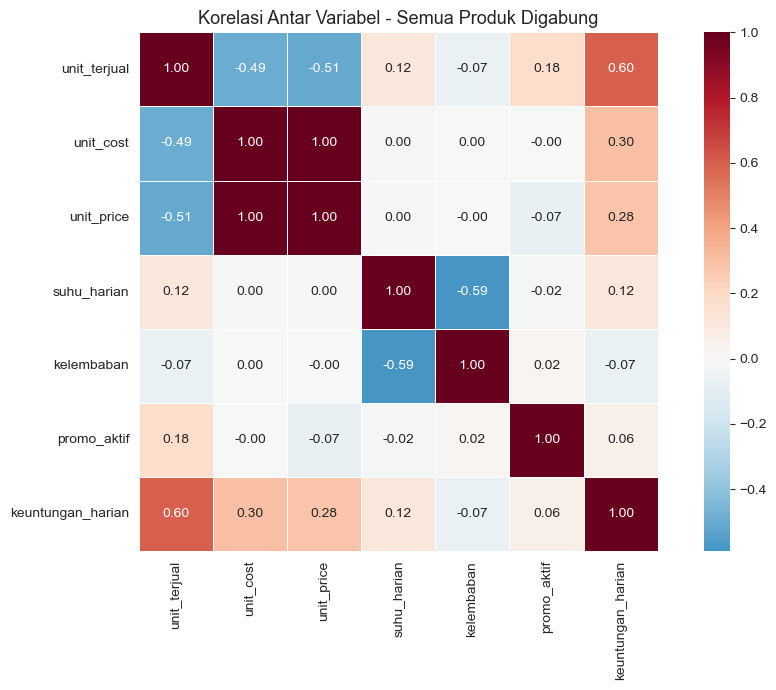

In [20]:
# Pilih hanya kolom numerik untuk dihitung korelasinya
kolom_numerik = ['unit_terjual', 'unit_cost', 'unit_price', 'suhu_harian',
                  'kelembaban', 'promo_aktif', 'keuntungan_harian']

# Hitung matriks korelasi
matriks_korelasi = df[kolom_numerik].corr()

# Plot heatmap dengan seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(matriks_korelasi, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Korelasi Antar Variabel - Semua Produk Digabung', fontsize=13)
plt.tight_layout()
plt.show()


**Hmm, korelasi suhu vs penjualan kelihatan lemah (~0.12).** Tapi ini karena kita menggabungkan semua produk!

Bisa jadi **es krim** sangat dipengaruhi suhu, tapi **susu** tidak — kalau dirata-ratakan, efeknya jadi 'hilang'. Mari lihat per produk:


In [21]:
# Korelasi suhu vs unit_terjual untuk masing-masing produk
for produk in df['jenis_produk'].unique():
    subset = df[df['jenis_produk'] == produk]
    korelasi = subset['suhu_harian'].corr(subset['unit_terjual'])
    print(f'{produk:10s} → korelasi suhu vs penjualan: {korelasi:+.3f}')


es_krim    → korelasi suhu vs penjualan: +0.904
mentega    → korelasi suhu vs penjualan: -0.408
keju       → korelasi suhu vs penjualan: +0.079
susu       → korelasi suhu vs penjualan: +0.024
yogurt     → korelasi suhu vs penjualan: +0.488


**Sekarang ceritanya jelas:**
- 🍦 **es_krim** punya korelasi sangat tinggi dengan suhu — makin panas, makin laku
- 🥛 **susu** hampir tidak terpengaruh suhu (orang minum susu kapan saja)
- 🧈 **mentega** justru turun di hari panas (orang lebih suka makanan ringan saat panas)

Mari fokus ke **es_krim** dan modelkan hubungannya dengan linear regression.


### 5.2 Linear Regression: Memodelkan Hubungan Suhu vs Penjualan Es Krim

**Linear regression** = membuat **garis lurus** yang paling pas menggambarkan hubungan antara 2 variabel.

Bentuknya: `y = a*x + b`  
Dalam kasus kita: `penjualan_es_krim = a*suhu + b`

Komputer akan mencari nilai `a` (slope) dan `b` (intercept) yang membuat garis paling 'pas' dengan titik-titik data.


In [22]:
# Filter data hanya untuk es krim
es_krim = df[df['jenis_produk'] == 'es_krim'].copy()

# Siapkan data untuk model
# X = variabel prediktor (suhu), harus 2D - makanya pakai double bracket [[]]
# y = variabel target (yang ingin diprediksi)
X = es_krim[['suhu_harian']]
y = es_krim['unit_terjual']

# Buat dan latih model linear regression
model = LinearRegression()
model.fit(X, y)

# Lihat parameter yang dipelajari model
print(f'Slope (a) = {model.coef_[0]:.2f}')
print(f'Intercept (b) = {model.intercept_:.2f}')
print(f'R² (seberapa bagus model fit data) = {model.score(X, y):.3f}')
print()
print(f'Interpretasi: setiap kenaikan suhu 1°C → penjualan es krim naik ~{model.coef_[0]:.1f} unit')


Slope (a) = 6.91
Intercept (b) = -147.30
R² (seberapa bagus model fit data) = 0.817

Interpretasi: setiap kenaikan suhu 1°C → penjualan es krim naik ~6.9 unit


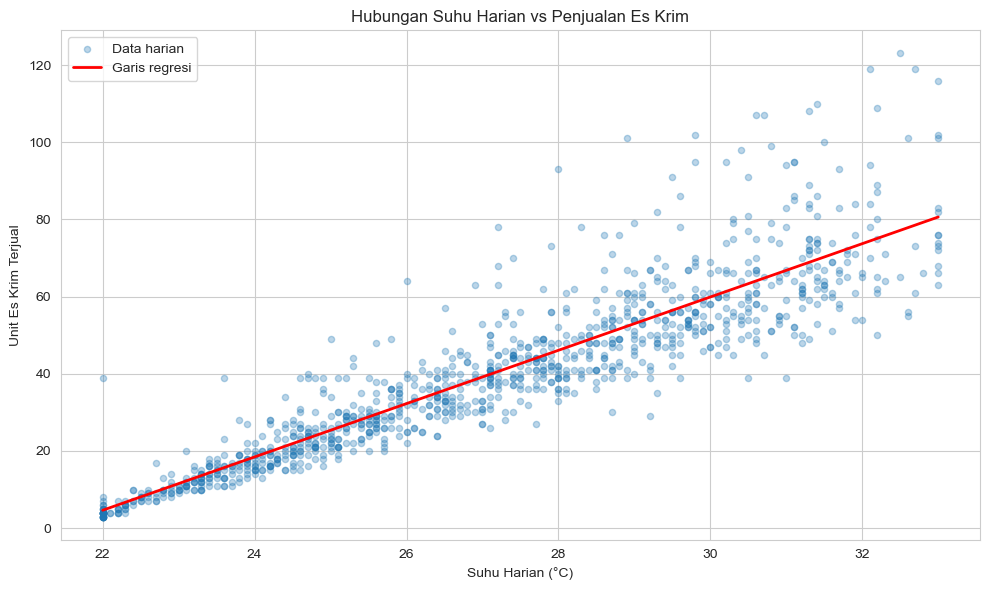

In [23]:
# Visualisasi: scatter plot + garis regresi
plt.figure(figsize=(10, 6))

# Scatter plot data asli
plt.scatter(es_krim['suhu_harian'], es_krim['unit_terjual'],
            alpha=0.3, s=20, label='Data harian')

# Hitung garis regresi - input prediksi pakai DataFrame supaya konsisten dengan training
suhu_range = np.linspace(es_krim['suhu_harian'].min(), es_krim['suhu_harian'].max(), 100)
suhu_range_df = pd.DataFrame({'suhu_harian': suhu_range})
prediksi = model.predict(suhu_range_df)
plt.plot(suhu_range, prediksi, color='red', linewidth=2, label='Garis regresi')

plt.xlabel('Suhu Harian (°C)')
plt.ylabel('Unit Es Krim Terjual')
plt.title('Hubungan Suhu Harian vs Penjualan Es Krim')
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 ⚠️ Pelajaran Penting: Model Bisa Bohong!

Sekarang kita punya model. Mari coba pakai untuk prediksi:


In [24]:
# Prediksi penjualan es krim di berbagai suhu
# Penting: format input prediksi harus SAMA dengan format saat melatih model
# (yaitu DataFrame dengan kolom 'suhu_harian')
suhu_uji = pd.DataFrame({'suhu_harian': [25, 28, 30]})  # suhu wajar di Boyolali

# predict() bisa terima banyak baris sekaligus - lebih efisien daripada looping
prediksi = model.predict(suhu_uji)

# Tampilkan hasilnya
for suhu, hasil in zip(suhu_uji['suhu_harian'], prediksi):
    print(f'Suhu {suhu}°C → prediksi penjualan: {hasil:.0f} unit es krim')


Suhu 25°C → prediksi penjualan: 25 unit es krim
Suhu 28°C → prediksi penjualan: 46 unit es krim
Suhu 30°C → prediksi penjualan: 60 unit es krim


In [26]:
# Sekarang coba angka yang TIDAK MASUK AKAL untuk Indonesia
suhu_aneh = pd.DataFrame({'suhu_harian': [50, -5, 100]})
prediksi_aneh = model.predict(suhu_aneh)

for suhu, hasil in zip(suhu_aneh['suhu_harian'], prediksi_aneh):
    print(f'Suhu {suhu}°C → prediksi penjualan: {hasil:.0f} unit es krim 🤨')


Suhu 50°C → prediksi penjualan: 198 unit es krim 🤨
Suhu -5°C → prediksi penjualan: -182 unit es krim 🤨
Suhu 100°C → prediksi penjualan: 543 unit es krim 🤨


### 🚨 Apa yang Terjadi?

Model **dengan senang hati** memberi prediksi untuk suhu 50°C, -5°C, bahkan 100°C. Tapi:
- Suhu 50°C tidak pernah terjadi di Boyolali (suhu tertinggi sekitar 33°C)
- Suhu -5°C? Tidak akan pernah (kita di tropis!)
- Prediksi pada suhu -5°C bahkan bisa keluar **angka negatif** (mustahil — kalian tidak mungkin menjual jumlah negatif es krim!)

**Pelajaran emas:**
> 🎯 **Model akan SELALU memberi jawaban — tapi tugas analis adalah menilai apakah jawaban itu MASUK AKAL.**

Konsep ini disebut **extrapolation**: menggunakan model di luar range data yang dipakai melatihnya. Sangat berbahaya. Selalu cek: apakah input prediksi kalian masih wajar dibandingkan data asli?


## 6️⃣ Insight #3: Produk Mana yang Penjualannya Paling Stabil? 📦

Pertanyaan terakhir manajer: **"Saya butuh tahu produk mana yang penjualannya bisa diandalkan (stabil) dan mana yang naik-turun ekstrim."**

Untuk pertanyaan ini, kita pakai **boxplot** — grafik yang menunjukkan **sebaran (spread)** data, bukan cuma rata-rata.

**Cara baca boxplot:**
- 📦 **Kotak** = 50% data tengah (Q1 sampai Q3)
- ➖ **Garis di tengah kotak** = median
- 📏 **Whisker** (garis perpanjangan) = sebaran wajar
- ⚫ **Titik-titik di luar whisker** = outlier (data ekstrim)

Kotak lebih lebar = penjualan lebih fluktuatif.


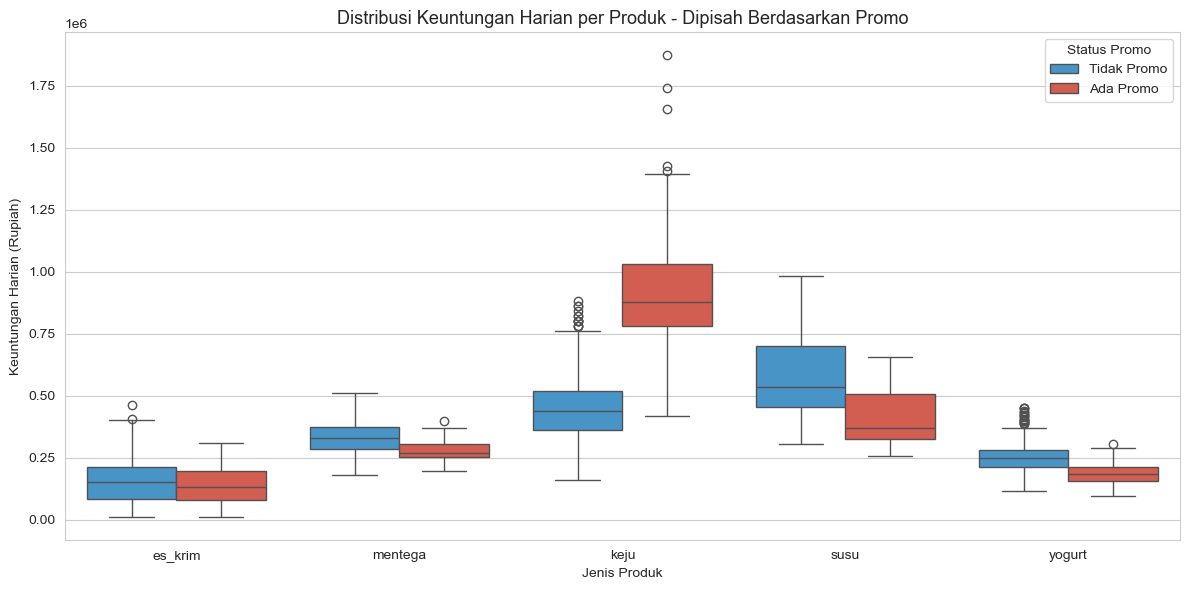

In [27]:
# Boxplot: distribusi keuntungan_harian per produk, dipisah berdasarkan promo

# Buat label deskriptif untuk legend (lebih jelas daripada angka 0/1)
df['promo_label'] = df['promo_aktif'].map({0: 'Tidak Promo', 1: 'Ada Promo'})

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='jenis_produk',
    y='keuntungan_harian',
    hue='promo_label',
    palette={'Tidak Promo': '#3498db', 'Ada Promo': '#e74c3c'},  # biru vs merah
)
plt.title('Distribusi Keuntungan Harian per Produk - Dipisah Berdasarkan Promo', fontsize=13)
plt.xlabel('Jenis Produk')
plt.ylabel('Keuntungan Harian (Rupiah)')
plt.legend(title='Status Promo')
plt.tight_layout()
plt.show()


### 🤯 Cerita yang Diceritakan Boxplot Ini

Coba lihat **keju**:
- Di hari **tanpa promo** (biru): keuntungan keju **moderate dan stabil**
- Di hari **ada promo** (merah): keuntungan keju **melonjak DRASTIS** — kotak merah jauh lebih tinggi dari biru

Sekarang lihat **susu** atau **yogurt**:
- Kotak biru dan merah hampir sama tinggi — promo TIDAK terlalu berpengaruh
- Bahkan untuk beberapa produk, kotak merah sedikit lebih rendah (karena diskon mengurangi margin tanpa cukup menaikkan volume)

### 💡 Insight Bisnis untuk Manajer:

> **Strategi promo paling efektif untuk KEJU**, bukan untuk produk lain.  
> Kalau koperasi mau bikin diskon, fokuskan ke keju — di situ lah dampaknya paling besar.  
> Untuk produk lain (susu, yogurt, mentega), diskon malah mengurangi keuntungan tanpa cukup menaikkan volume.

Ini adalah contoh **data-driven decision making** yang nyata: keputusan bisnis didukung oleh bukti dari data, bukan tebakan.


In [28]:
# Konfirmasi numerik: berapa rata-rata keuntungan per produk, dipisah promo?
ringkasan_promo = df.groupby(['jenis_produk', 'promo_aktif'])['keuntungan_harian'].mean().unstack()
ringkasan_promo.columns = ['Tanpa Promo', 'Dengan Promo']
ringkasan_promo['Selisih (%)'] = ((ringkasan_promo['Dengan Promo'] / ringkasan_promo['Tanpa Promo'] - 1) * 100).round(1)
ringkasan_promo.round(0)


,Tanpa Promo,Dengan Promo,Selisih (%)
jenis_produk,,,
es_krim,152350.0,138986.0,-9.0
keju,449333.0,928755.0,107.0
mentega,327609.0,276792.0,-16.0
susu,573961.0,411203.0,-28.0
yogurt,249872.0,186255.0,-26.0


## 7️⃣ Ringkasan & Rekomendasi untuk Koperasi Susu Boyolali 📋

### Apa yang Kita Temukan Hari Ini:

**1. Tren Penjualan Naik Sejak Awal 2025** 📈  
Penjualan mingguan koperasi rata-rata naik **~28%** sejak program **Makan Bergizi Gratis (MBG)** diluncurkan 6 Januari 2025. Susu jadi komponen kunci menu sekolah.  
→ **Rekomendasi:** Pastikan kapasitas produksi susu mencukupi untuk memenuhi pesanan sekolah yang masih bisa terus bertambah.

**2. Suhu Mempengaruhi Beberapa Produk (Bukan Semua)** 🌡️  
Penjualan **es krim** sangat dipengaruhi suhu (korelasi >+0.9). **Susu** hampir tidak terpengaruh. **Mentega** justru turun di hari panas.  
→ **Rekomendasi:** Tingkatkan stok es krim di musim kemarau (Mei-Oktober). Kurangi produksi mentega saat suhu tinggi.

**3. Strategi Promo Sebaiknya Difokuskan ke Keju** 🧀  
Promo melonjakkan keuntungan keju **+100%** lebih. Untuk produk lain, promo malah mengurangi keuntungan karena diskon mengikis margin tanpa cukup menaikkan volume.  
→ **Rekomendasi:** Jalankan kampanye promo khusus keju (paket bundling, diskon volume, dll). Hentikan atau kurangi promo untuk produk lain.

### 🚨 Catatan Penting (Limitasi Analisis):
Model linear regression kami akurat dalam range suhu 22-33°C (range data Boyolali). Jangan gunakan model ini untuk memprediksi penjualan di suhu di luar range tersebut — hasilnya tidak bisa dipercaya.


## 8️⃣ Selamat! Kalian Baru Saja Menjadi Data Analyst 🎉

Dalam 2,5 jam, kalian sudah belajar:

✅ Memuat dataset dari URL  
✅ Eksplorasi awal data (`head`, `info`, `describe`)  
✅ Membersihkan data (missing values, duplikat, inkonsistensi)  
✅ Membuat kolom baru (feature engineering)  
✅ Agregasi & visualisasi tren (line chart interaktif)  
✅ Analisis korelasi (heatmap)  
✅ Membangun model machine learning sederhana (linear regression)  
✅ Mengenali bahaya extrapolation  
✅ Memahami distribusi data (boxplot)  
✅ Menyusun rekomendasi bisnis berbasis data

**Workflow yang baru kalian jalani ini sama persis dengan yang dipakai data analyst di Tokopedia, Gojek, Cimory, Greenfields, dan perusahaan-perusahaan lain.** Bedanya cuma skala data dan jenis bisnis. Fundamentalnya sama.

### 📥 Cara Export Laporan Ini Jadi PDF

1. Di Colab: klik **File** → **Print** (atau Ctrl+P)
2. Pilih **"Save as PDF"** sebagai printer
3. Klik **Save**

Hasilnya: laporan analisis kalian lengkap dengan grafik dan kesimpulan — siap dipresentasikan ke manajer, atau dimasukkan ke portofolio kalian!

---

### 🚀 Kemana Setelah Ini?

Kalau kalian tertarik melanjutkan:
- **Kaggle** (kaggle.com) — platform belajar data science dengan banyak dataset gratis & kompetisi
- **YouTube channels Bahasa Indonesia:** Indra Krishnamurthi, Sains Data
- **Lanjutan:** machine learning yang lebih kompleks (decision trees, neural networks), SQL, Tableau/Power BI

**Selamat berkarya, data scientists muda Boyolali! 🚀**
